# Tree Model Options

This notebook explores tree-based models on the same original baseline source-variable set used in notebook 01. The goal is to let trees discover nonlinear splits and interactions directly, rather than starting from the L1-selected variable list.

Models included:

- Random Forest
- Histogram Gradient Boosting

Outputs saved to `model_dev/artifacts`:

- `tree_model_metrics_compare.csv`
- `tree_impurity_source_feature_importance.csv`
- `tree_permutation_source_feature_importance.csv`


In [1]:
from pathlib import Path
import inspect
import warnings

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)

ROOT = Path('/Users/jinyecai/Desktop/ML_Mortgage')
PROC = ROOT / 'processed_mortgage'
ARTIFACT_DIR = Path('/Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

CLEANED_DIR = PROC / 'cleaned'
default_fe_path = CLEANED_DIR / 'default_fe.parquet'
prepay_fe_path = CLEANED_DIR / 'prepay_fe.parquet'

if not default_fe_path.exists() or not prepay_fe_path.exists():
    raise FileNotFoundError(
        'Missing cleaned feature-engineered parquet files. '
        'Please run notebook 01 through the cleaned-data export first.'
    )

default_fe = pd.read_parquet(default_fe_path)
prepay_fe = pd.read_parquet(prepay_fe_path)

print(f'default_fe: {default_fe.shape}')
print(f'prepay_fe:  {prepay_fe.shape}')
print(f'artifacts:  {ARTIFACT_DIR}')


default_fe: (1785162, 47)
prepay_fe:  (1785162, 47)
artifacts:  /Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts


## Shared Split, Metrics, and Baseline Feature Set

The split below matches the earlier notebooks: train/test is done at `loan_id` level, stratified by whether the loan ever experiences the target event.


In [2]:
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

BASELINE_EXCLUDE_COLS = {
    'loan_id',
    'rp_yyyymm',
    'first_payment_date',
    'maturity_date',
    'first_payment_date_dt',
    'maturity_date_dt',
    'postal_code',
    'msa_code',
    'seller_name',
    'servicer_name',
    'current_actual_upb',
    'year',
}


def coerce_numeric_like(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        series = df[col]
        if not (pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)):
            continue
        cleaned = series.astype('string').replace({'': pd.NA, '<NA>': pd.NA})
        converted = pd.to_numeric(cleaned, errors='coerce')
        if cleaned.notna().sum() == converted.notna().sum():
            df[col] = converted
        else:
            df[col] = cleaned
    return df


def prepare_baseline_frame(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: list[str] | None = None,
):
    loan_ids = df['loan_id'].copy()
    y = df[target_col].astype(int).copy()
    X = df.drop(columns=[target_col]).copy()

    drop_cols = [col for col in BASELINE_EXCLUDE_COLS if col in X.columns]
    X = X.drop(columns=drop_cols)
    X = coerce_numeric_like(X)

    if feature_cols is not None:
        missing_feature_cols = [col for col in feature_cols if col not in X.columns]
        if missing_feature_cols:
            raise KeyError(f'Requested feature_cols not found: {missing_feature_cols[:10]}')
        X = X.loc[:, feature_cols].copy()

    return X, y, loan_ids


def evaluate_binary_predictions(y_true, y_score) -> dict:
    y_score_clipped = np.clip(y_score, 1e-12, 1 - 1e-12)
    return {
        'test_event_rate': float(np.mean(y_true)),
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'log_loss': float(log_loss(y_true, y_score_clipped, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, y_score)),
    }


def build_train_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: list[str] | None = None,
    test_size: float = 0.2,
    random_state: int = 42,
):
    X, y, loan_ids = prepare_baseline_frame(df, target_col=target_col, feature_cols=feature_cols)

    loan_level_target = pd.DataFrame({
        'loan_id': loan_ids,
        target_col: y,
    }).groupby('loan_id')[target_col].max()

    train_loans, test_loans = train_test_split(
        loan_level_target.index,
        test_size=test_size,
        random_state=random_state,
        stratify=loan_level_target.values,
    )

    train_mask = loan_ids.isin(train_loans).to_numpy()
    test_mask = loan_ids.isin(test_loans).to_numpy()

    return (
        X.loc[train_mask].copy(),
        X.loc[test_mask].copy(),
        y.loc[train_mask].copy(),
        y.loc[test_mask].copy(),
    )


def stratified_row_sample(
    X: pd.DataFrame,
    y: pd.Series,
    max_rows: int | None,
    random_state: int = 42,
):
    if max_rows is None or len(y) <= max_rows:
        return X.copy(), y.copy()

    class_counts = y.value_counts()
    stratify = y if class_counts.min() >= 2 else None

    X_sample, _, y_sample, _ = train_test_split(
        X,
        y,
        train_size=max_rows,
        random_state=random_state,
        stratify=stratify,
    )
    return X_sample.copy(), y_sample.copy()


## Preprocessing and Feature-Name Mapping

Tree models use the original baseline source variables. Categorical variables are one-hot encoded so that the preprocessing remains consistent with the earlier linear models. Importance is then aggregated back to source-variable level.


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def make_one_hot_encoder(drop='first', sparse_output=True):
    params = {
        'handle_unknown': 'ignore',
        'drop': drop,
    }
    if 'sparse_output' in inspect.signature(OneHotEncoder).parameters:
        params['sparse_output'] = sparse_output
    else:
        params['sparse'] = sparse_output
    return OneHotEncoder(**params)


def split_feature_types(X_train: pd.DataFrame):
    categorical_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    numeric_cols = [col for col in X_train.columns if col not in categorical_cols]
    return categorical_cols, numeric_cols


def build_tree_preprocessor(X_train: pd.DataFrame, sparse_output: bool = True) -> ColumnTransformer:
    categorical_cols, numeric_cols = split_feature_types(X_train)

    transformers = []
    if numeric_cols:
        transformers.append(('num', SimpleImputer(strategy='median'), numeric_cols))
    if categorical_cols:
        transformers.append((
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', make_one_hot_encoder(drop='first', sparse_output=sparse_output)),
            ]),
            categorical_cols,
        ))

    return ColumnTransformer(transformers=transformers, remainder='drop')


def map_encoded_feature_to_source(encoded_name: str, raw_categorical_cols: list[str]) -> str:
    if encoded_name.startswith('num__'):
        return encoded_name.split('num__', 1)[1]

    if encoded_name.startswith('cat__'):
        raw = encoded_name.split('cat__', 1)[1]
        matches = [col for col in raw_categorical_cols if raw == col or raw.startswith(f'{col}_')]
        if matches:
            return max(matches, key=len)
        return raw

    return encoded_name


def get_encoded_feature_names(model: Pipeline) -> list[str]:
    return model.named_steps['preprocessor'].get_feature_names_out().tolist()


## Model Builders

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

TREE_CONFIG = {
    'test_size': 0.2,
    'random_state': 66,
    'max_train_rows': None,
    'importance_max_rows': 50_000,
    'permutation_repeats': 5,
    'permutation_scoring': 'average_precision',
}


def build_tree_model(model_name: str, X_train: pd.DataFrame, random_state: int = 66) -> Pipeline:
    if model_name == 'random_forest':
        preprocessor = build_tree_preprocessor(X_train, sparse_output=True)
        classifier = RandomForestClassifier(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=50,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=random_state,
        )
    elif model_name == 'hist_gradient_boosting':
        preprocessor = build_tree_preprocessor(X_train, sparse_output=False)
        classifier = HistGradientBoostingClassifier(
            loss='log_loss',
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=31,
            min_samples_leaf=50,
            l2_regularization=0.01,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=random_state,
        )
    else:
        raise ValueError(f'Unknown model_name={model_name!r}')

    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', classifier),
    ])


def fit_tree_model(
    model: Pipeline,
    model_name: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
):
    fit_kwargs = {}
    if model_name == 'hist_gradient_boosting':
        fit_kwargs['classifier__sample_weight'] = compute_sample_weight(
            class_weight='balanced',
            y=y_train,
        )
    model.fit(X_train, y_train, **fit_kwargs)
    return model


## Variable Importance Helpers

For Random Forest, impurity importance is available after fitting. For both models, grouped permutation importance is computed on raw source variables by permuting one original column at a time before the preprocessing pipeline.


In [5]:
from sklearn.inspection import permutation_importance


def source_importance_from_encoded_importance(
    model: Pipeline,
    outcome: str,
    model_name: str,
    X_train: pd.DataFrame,
) -> pd.DataFrame:
    classifier = model.named_steps['classifier']
    if not hasattr(classifier, 'feature_importances_'):
        return pd.DataFrame()

    raw_categorical_cols, _ = split_feature_types(X_train)
    encoded_feature_names = get_encoded_feature_names(model)

    encoded_importance = pd.DataFrame({
        'encoded_feature': encoded_feature_names,
        'importance': classifier.feature_importances_,
    })
    encoded_importance['source_feature'] = encoded_importance['encoded_feature'].map(
        lambda x: map_encoded_feature_to_source(x, raw_categorical_cols)
    )

    source_importance = (
        encoded_importance
        .groupby('source_feature', as_index=False)
        .agg(
            importance=('importance', 'sum'),
            max_encoded_importance=('importance', 'max'),
            n_encoded_features=('encoded_feature', 'size'),
        )
        .sort_values(['importance', 'max_encoded_importance'], ascending=[False, False])
        .reset_index(drop=True)
    )
    source_importance.insert(0, 'model', model_name)
    source_importance.insert(0, 'outcome', outcome)
    source_importance['importance_rank'] = np.arange(1, len(source_importance) + 1)
    return source_importance


def raw_permutation_importance(
    model: Pipeline,
    outcome: str,
    model_name: str,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    max_rows: int | None = 50_000,
    n_repeats: int = 5,
    scoring: str = 'average_precision',
    random_state: int = 42,
) -> pd.DataFrame:
    X_imp, y_imp = stratified_row_sample(
        X_test,
        y_test,
        max_rows=max_rows,
        random_state=random_state,
    )

    result = permutation_importance(
        model,
        X_imp,
        y_imp,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
    )

    importance = pd.DataFrame({
        'source_feature': X_imp.columns,
        'permutation_importance_mean': result.importances_mean,
        'permutation_importance_std': result.importances_std,
    })
    importance = (
        importance
        .sort_values(['permutation_importance_mean', 'permutation_importance_std'], ascending=[False, False])
        .reset_index(drop=True)
    )
    importance.insert(0, 'model', model_name)
    importance.insert(0, 'outcome', outcome)
    importance['importance_rank'] = np.arange(1, len(importance) + 1)
    importance['scoring'] = scoring
    importance['n_repeats'] = n_repeats
    importance['n_rows'] = len(y_imp)
    importance['event_rate'] = float(y_imp.mean())
    return importance


## Run Tree Experiments

The loop below trains both tree models for prepayment and default, evaluates them on the held-out loan-level test set, and saves the comparison and importance tables.


In [6]:
def run_tree_experiment(
    df: pd.DataFrame,
    target_col: str,
    outcome: str,
    model_name: str,
    test_size: float = 0.2,
    random_state: int = 42,
    max_train_rows: int | None = 400_000,
    importance_max_rows: int | None = 50_000,
    permutation_repeats: int = 5,
    permutation_scoring: str = 'average_precision',
):
    X_train, X_test, y_train, y_test = build_train_test_split(
        df,
        target_col=target_col,
        test_size=test_size,
        random_state=random_state,
    )

    X_fit, y_fit = stratified_row_sample(
        X_train,
        y_train,
        max_rows=max_train_rows,
        random_state=random_state,
    )

    model = build_tree_model(model_name, X_fit, random_state=random_state)
    model = fit_tree_model(model, model_name, X_fit, y_fit)

    y_score = model.predict_proba(X_test)[:, 1]
    metrics = evaluate_binary_predictions(y_test, y_score)
    encoded_feature_names = get_encoded_feature_names(model)

    metrics_row = {
        'outcome': outcome,
        'model': model_name,
        'feature_definition': 'baseline original source variables',
        'train_rows_available': int(X_train.shape[0]),
        'train_rows_fit': int(X_fit.shape[0]),
        'test_rows': int(X_test.shape[0]),
        'n_features_raw': int(X_train.shape[1]),
        'n_features_encoded': int(len(encoded_feature_names)),
        **metrics,
    }

    impurity_importance = source_importance_from_encoded_importance(
        model=model,
        outcome=outcome,
        model_name=model_name,
        X_train=X_fit,
    )

    permutation = raw_permutation_importance(
        model=model,
        outcome=outcome,
        model_name=model_name,
        X_test=X_test,
        y_test=y_test,
        max_rows=importance_max_rows,
        n_repeats=permutation_repeats,
        scoring=permutation_scoring,
        random_state=random_state,
    )

    return {
        'model': model,
        'metrics_row': metrics_row,
        'impurity_importance': impurity_importance,
        'permutation_importance': permutation,
    }


experiments = [
    {'outcome': 'prepay', 'target_col': 'y_prepay', 'df': prepay_fe},
    {'outcome': 'default', 'target_col': 'y_default', 'df': default_fe},
]
model_names = ['random_forest', 'hist_gradient_boosting']

tree_results = {}
metrics_rows = []
impurity_tables = []
permutation_tables = []

for experiment in experiments:
    for model_name in model_names:
        outcome = experiment['outcome']
        print(f'Running {model_name} for {outcome}...')
        result = run_tree_experiment(
            df=experiment['df'],
            target_col=experiment['target_col'],
            outcome=outcome,
            model_name=model_name,
            **TREE_CONFIG,
        )
        tree_results[(outcome, model_name)] = result
        metrics_rows.append(result['metrics_row'])
        if not result['impurity_importance'].empty:
            impurity_tables.append(result['impurity_importance'])
        permutation_tables.append(result['permutation_importance'])


tree_metrics = pd.DataFrame(metrics_rows).round(6)
tree_impurity_importance = (
    pd.concat(impurity_tables, ignore_index=True)
    if impurity_tables else
    pd.DataFrame()
)
tree_permutation_importance = pd.concat(permutation_tables, ignore_index=True)

metrics_output_path = ARTIFACT_DIR / 'tree_model_metrics_compare.csv'
impurity_output_path = ARTIFACT_DIR / 'tree_impurity_source_feature_importance.csv'
permutation_output_path = ARTIFACT_DIR / 'tree_permutation_source_feature_importance.csv'

tree_metrics.to_csv(metrics_output_path, index=False)
if not tree_impurity_importance.empty:
    tree_impurity_importance.to_csv(impurity_output_path, index=False)
tree_permutation_importance.to_csv(permutation_output_path, index=False)

print('\nTree model metrics:')
print(tree_metrics.to_string(index=False))
print(f'\nSaved metrics to {metrics_output_path}')
if not tree_impurity_importance.empty:
    print(f'Saved impurity importance to {impurity_output_path}')
print(f'Saved permutation importance to {permutation_output_path}')


Running random_forest for prepay...
Running hist_gradient_boosting for prepay...
Running random_forest for default...
Running hist_gradient_boosting for default...

Tree model metrics:
outcome                  model                 feature_definition  train_rows_available  train_rows_fit  test_rows  n_features_raw  n_features_encoded  test_event_rate  roc_auc   pr_auc  log_loss  brier_score
 prepay          random_forest baseline original source variables               1429805         1429805     355357              35                  46         0.010769 0.969081 0.533129  0.106118     0.026366
 prepay hist_gradient_boosting baseline original source variables               1429805         1429805     355357              35                  46         0.010769 0.972572 0.581481  0.159306     0.040392
default          random_forest baseline original source variables               1429880         1429880     355282              35                  46         0.000811 0.850188 0.018184  0

## Review Metrics


In [7]:
tree_metrics.sort_values(['outcome', 'pr_auc', 'roc_auc'], ascending=[True, False, False])


,outcome,model,feature_definition,train_rows_available,train_rows_fit,test_rows,n_features_raw,n_features_encoded,test_event_rate,roc_auc,pr_auc,log_loss,brier_score
3,default,hist_gradient_boosting,baseline original source variables,1429880,1429880,355282,35,46,0.000811,0.885922,0.018870,0.330093,0.101834
2,default,random_forest,baseline original source variables,1429880,1429880,355282,35,46,0.000811,0.850188,0.018184,0.031801,0.004708
1,prepay,hist_gradient_boosting,baseline original source variables,1429805,1429805,355357,35,46,0.010769,0.972572,0.581481,0.159306,0.040392
0,prepay,random_forest,baseline original source variables,1429805,1429805,355357,35,46,0.010769,0.969081,0.533129,0.106118,0.026366


## Top Important Variables

Permutation importance is usually the more useful table for model interpretation here because it measures held-out performance deterioration after shuffling each original source variable.


In [8]:
TOP_N = 20

for outcome in ['prepay', 'default']:
    for model_name in model_names:
        print(f'\nTop {TOP_N} permutation importances: {outcome} / {model_name}')
        display(
            tree_permutation_importance
            .query('outcome == @outcome and model == @model_name')
            .head(TOP_N)
        )



Top 20 permutation importances: prepay / random_forest


,outcome,model,source_feature,permutation_importance_mean,permutation_importance_std,importance_rank,scoring,n_repeats,n_rows,event_rate
0,prepay,random_forest,estimated_loan_to_value_eltv,0.514522,0.001691,1,average_precision,5,50000,0.01076
1,prepay,random_forest,property_type,0.100941,0.010355,2,average_precision,5,50000,0.01076
2,prepay,random_forest,loan_age,0.085613,0.006436,3,average_precision,5,50000,0.01076
3,prepay,random_forest,original_upb,0.062691,0.002586,4,average_precision,5,50000,0.01076
4,prepay,random_forest,pmms30,0.041076,0.008808,5,average_precision,5,50000,0.01076
5,prepay,random_forest,number_of_units,0.038812,0.003569,6,average_precision,5,50000,0.01076
6,prepay,random_forest,incentive_rate,0.037089,0.011785,7,average_precision,5,50000,0.01076
7,prepay,random_forest,gs10,0.030480,0.008829,8,average_precision,5,50000,0.01076
8,prepay,random_forest,vintage_group,0.023615,0.005681,9,average_precision,5,50000,0.01076
9,prepay,random_forest,mortgage_insurance_cancellation_indicator,0.020943,0.003097,10,average_precision,5,50000,0.01076



Top 20 permutation importances: prepay / hist_gradient_boosting


,outcome,model,source_feature,permutation_importance_mean,permutation_importance_std,importance_rank,scoring,n_repeats,n_rows,event_rate
35,prepay,hist_gradient_boosting,estimated_loan_to_value_eltv,0.562286,0.000983,1,average_precision,5,50000,0.01076
36,prepay,hist_gradient_boosting,property_type,0.158792,0.013734,2,average_precision,5,50000,0.01076
37,prepay,hist_gradient_boosting,loan_age,0.133140,0.011819,3,average_precision,5,50000,0.01076
38,prepay,hist_gradient_boosting,number_of_units,0.064167,0.004855,4,average_precision,5,50000,0.01076
39,prepay,hist_gradient_boosting,original_upb,0.052577,0.006561,5,average_precision,5,50000,0.01076
40,prepay,hist_gradient_boosting,incentive_rate,0.052344,0.005661,6,average_precision,5,50000,0.01076
41,prepay,hist_gradient_boosting,current_interest_rate,0.023889,0.009007,7,average_precision,5,50000,0.01076
42,prepay,hist_gradient_boosting,cpi,0.022579,0.006010,8,average_precision,5,50000,0.01076
43,prepay,hist_gradient_boosting,fedfunds,0.022399,0.006932,9,average_precision,5,50000,0.01076
44,prepay,hist_gradient_boosting,mortgage_insurance_cancellation_indicator,0.016355,0.005007,10,average_precision,5,50000,0.01076



Top 20 permutation importances: default / random_forest


,outcome,model,source_feature,permutation_importance_mean,permutation_importance_std,importance_rank,scoring,n_repeats,n_rows,event_rate
70,default,random_forest,credit_score,5.306268e-03,0.006251,1,average_precision,5,50000,0.00082
71,default,random_forest,dti,5.178011e-03,0.006909,2,average_precision,5,50000,0.00082
72,default,random_forest,pmms30,2.693236e-03,0.003453,3,average_precision,5,50000,0.00082
73,default,random_forest,fedfunds,2.080961e-03,0.001964,4,average_precision,5,50000,0.00082
74,default,random_forest,median_aqi,1.706675e-03,0.001090,5,average_precision,5,50000,0.00082
75,default,random_forest,original_upb,9.158123e-04,0.008524,6,average_precision,5,50000,0.00082
76,default,random_forest,first_time_homebuyer_flag,8.926317e-04,0.000647,7,average_precision,5,50000,0.00082
77,default,random_forest,number_of_borrowers,6.666454e-04,0.001018,8,average_precision,5,50000,0.00082
78,default,random_forest,occupancy_status,2.548409e-04,0.002080,9,average_precision,5,50000,0.00082
79,default,random_forest,mortgage_insurance_cancellation_indicator,7.065328e-07,0.000106,10,average_precision,5,50000,0.00082



Top 20 permutation importances: default / hist_gradient_boosting


,outcome,model,source_feature,permutation_importance_mean,permutation_importance_std,importance_rank,scoring,n_repeats,n_rows,event_rate
105,default,hist_gradient_boosting,unrate,0.029838,9.232164e-04,1,average_precision,5,50000,0.00082
106,default,hist_gradient_boosting,credit_score,0.012115,4.529826e-03,2,average_precision,5,50000,0.00082
107,default,hist_gradient_boosting,cpi,0.008867,3.497627e-03,3,average_precision,5,50000,0.00082
108,default,hist_gradient_boosting,pmms30,0.008684,4.099660e-03,4,average_precision,5,50000,0.00082
109,default,hist_gradient_boosting,original_upb,0.007195,9.234457e-03,5,average_precision,5,50000,0.00082
110,default,hist_gradient_boosting,loan_age,0.006306,8.276336e-03,6,average_precision,5,50000,0.00082
111,default,hist_gradient_boosting,fhfa_hpi_yoy,0.004452,4.669953e-03,7,average_precision,5,50000,0.00082
112,default,hist_gradient_boosting,mortgage_insurance_cancellation_indicator,0.001268,9.104323e-05,8,average_precision,5,50000,0.00082
113,default,hist_gradient_boosting,occupancy_status,0.000787,1.596636e-03,9,average_precision,5,50000,0.00082
114,default,hist_gradient_boosting,vintage_group,0.000764,1.627272e-03,10,average_precision,5,50000,0.00082


In [ ]:
if not tree_impurity_importance.empty:
    for outcome in ['prepay', 'default']:
        print(f'\nTop {TOP_N} Random Forest impurity importances: {outcome}')
        display(
            tree_impurity_importance
            .query('outcome == @outcome and model == "random_forest"')
            .head(TOP_N)
        )



Top 20 Random Forest impurity importances: prepay


,outcome,model,source_feature,importance,max_encoded_importance,n_encoded_features,importance_rank
0,prepay,random_forest,estimated_loan_to_value_eltv,0.621617,0.621617,1,1
1,prepay,random_forest,incentive_rate,0.047121,0.047121,1,2
2,prepay,random_forest,loan_age,0.031944,0.031944,1,3
3,prepay,random_forest,pmms30,0.031486,0.031486,1,4
4,prepay,random_forest,gs10,0.028883,0.028883,1,5
5,prepay,random_forest,original_upb,0.019756,0.019756,1,6
6,prepay,random_forest,fedfunds,0.019294,0.019294,1,7
7,prepay,random_forest,cpi,0.018986,0.018986,1,8
8,prepay,random_forest,fhfa_hpi_yoy,0.017271,0.017271,1,9
9,prepay,random_forest,unrate,0.015437,0.015437,1,10



Top 20 Random Forest impurity importances: default


,outcome,model,source_feature,importance,max_encoded_importance,n_encoded_features,importance_rank
35,default,random_forest,credit_score,0.121697,0.121697,1,1
36,default,random_forest,gs10,0.068047,0.068047,1,2
37,default,random_forest,cpi_yoy,0.062631,0.062631,1,3
38,default,random_forest,unrate,0.062283,0.062283,1,4
39,default,random_forest,pmms30,0.058390,0.058390,1,5
40,default,random_forest,loan_age,0.053735,0.053735,1,6
41,default,random_forest,spread_at_origination,0.048030,0.048030,1,7
42,default,random_forest,dti,0.043691,0.043691,1,8
43,default,random_forest,original_upb,0.039940,0.039940,1,9
44,default,random_forest,fhfa_hpi_yoy,0.039760,0.039760,1,10


Exception ignored in: <function ResourceTracker.__del__ at 0x107ee9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107c59bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106265bc0>
Traceback (most recent call last

## Optional: Combine With Previous L1 / Spline Results


In [10]:
previous_comparison_path = ARTIFACT_DIR / 'l1_vs_spline_model_comparison.csv'

if previous_comparison_path.exists():
    previous_comparison = pd.read_csv(previous_comparison_path)
    tree_comparison = tree_metrics.rename(columns={
        'train_rows_fit': 'train_rows',
        'n_features_encoded': 'n_model_input_features',
    })[
        [
            'outcome',
            'model',
            'feature_definition',
            'train_rows',
            'test_rows',
            'n_model_input_features',
            'test_event_rate',
            'roc_auc',
            'pr_auc',
            'log_loss',
            'brier_score',
        ]
    ]

    combined_model_comparison = pd.concat(
        [previous_comparison, tree_comparison],
        ignore_index=True,
    ).round(6)

    combined_output_path = ARTIFACT_DIR / 'l1_spline_tree_model_comparison.csv'
    combined_model_comparison.to_csv(combined_output_path, index=False)
    print(f'Saved combined comparison to {combined_output_path}')
    display(combined_model_comparison)
else:
    print('No l1_vs_spline_model_comparison.csv found. Run notebook 02 if you want the combined table.')


Saved combined comparison to /Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts/l1_spline_tree_model_comparison.csv


,outcome,model,feature_definition,train_rows,test_rows,n_model_input_features,test_event_rate,roc_auc,pr_auc,log_loss,brier_score
0,prepay,l1_baseline_from_01,exact encoded features selected by L1,1430718,354444,33,0.010797,0.961675,0.442278,0.029538,0.007617
1,prepay,spline_on_l1_source_vars,selected source variables from L1 with spline ...,1430718,354444,113,0.010797,0.963840,0.514306,0.027268,0.006938
2,default,l1_baseline_from_01,exact encoded features selected by L1,1424249,360913,17,0.000798,0.798036,0.004624,0.006101,0.000796
3,default,spline_on_l1_source_vars,selected source variables from L1 with spline ...,1424249,360913,70,0.000798,0.832383,0.012072,0.005655,0.000793
4,prepay,random_forest,baseline original source variables,1429805,355357,46,0.010769,0.969081,0.533129,0.106118,0.026366
5,prepay,hist_gradient_boosting,baseline original source variables,1429805,355357,46,0.010769,0.972572,0.581481,0.159306,0.040392
6,default,random_forest,baseline original source variables,1429880,355282,46,0.000811,0.850188,0.018184,0.031801,0.004708
7,default,hist_gradient_boosting,baseline original source variables,1429880,355282,46,0.000811,0.885922,0.018870,0.330093,0.101834


## ROC-AUC Comparison Table

Compact ROC-AUC summary from already-run model metric artifacts.


In [ ]:
BASELINE_METRICS_PATH = ARTIFACT_DIR / 'baseline_logistic_metrics_compare.csv'
L1_SPLINE_METRICS_PATH = ARTIFACT_DIR / 'l1_vs_spline_model_comparison.csv'
TREE_METRICS_PATH = ARTIFACT_DIR / 'tree_model_metrics_compare.csv'

required_metric_paths = {
    'baseline logistic-style': BASELINE_METRICS_PATH,
    'L1 + spline': L1_SPLINE_METRICS_PATH,
    'tree models': TREE_METRICS_PATH,
}
missing_metric_paths = {
    name: path for name, path in required_metric_paths.items()
    if not path.exists()
}
if missing_metric_paths:
    raise FileNotFoundError(
        'Missing already-run metric artifacts. Rerun the corresponding notebook(s): '
        f'{missing_metric_paths}'
    )

baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH)
l1_spline_metrics = pd.read_csv(L1_SPLINE_METRICS_PATH)
tree_metrics_from_file = pd.read_csv(TREE_METRICS_PATH)

if 'outcome' not in baseline_metrics.columns:
    baseline_metrics['outcome'] = baseline_metrics['model'].str.replace('_baseline', '', regex=False)

baseline_summary = (
    baseline_metrics
    .assign(
        model='Baseline logistic-style model',
        n_input_features=baseline_metrics['n_features_encoded'],
    )
    [['outcome', 'model', 'n_input_features', 'roc_auc']]
)

l1_spline_summary = (
    l1_spline_metrics
    .loc[l1_spline_metrics['model'].isin(['l1_baseline_from_01', 'spline_on_l1_source_vars'])]
    .assign(
        model=lambda df: df['model'].map({
            'l1_baseline_from_01': 'L1 selected model',
            'spline_on_l1_source_vars': 'Cubic spline model',
        }),
        n_input_features=lambda df: df['n_model_input_features'],
    )
    [['outcome', 'model', 'n_input_features', 'roc_auc']]
)

tree_summary = (
    tree_metrics_from_file
    .loc[tree_metrics_from_file['model'].isin(['random_forest', 'hist_gradient_boosting'])]
    .assign(
        model=lambda df: df['model'].map({
            'random_forest': 'Random Forest',
            'hist_gradient_boosting': 'Histogram Gradient Boosting',
        }),
        n_input_features=lambda df: df['n_features_encoded'],
    )
    [['outcome', 'model', 'n_input_features', 'roc_auc']]
)

outcome_order = ['prepay', 'default']
model_order = [
    'Baseline logistic-style model',
    'L1 selected model',
    'Cubic spline model',
    'Random Forest',
    'Histogram Gradient Boosting',
]

roc_auc_model_comparison = pd.concat(
    [baseline_summary, l1_spline_summary, tree_summary],
    ignore_index=True,
)
roc_auc_model_comparison['outcome'] = pd.Categorical(
    roc_auc_model_comparison['outcome'],
    categories=outcome_order,
    ordered=True,
)
roc_auc_model_comparison['model'] = pd.Categorical(
    roc_auc_model_comparison['model'],
    categories=model_order,
    ordered=True,
)
roc_auc_model_comparison = (
    roc_auc_model_comparison
    .sort_values(['outcome', 'model'])
    .reset_index(drop=True)
)
roc_auc_model_comparison['roc_auc'] = roc_auc_model_comparison['roc_auc'].round(6)

roc_auc_model_comparison_path = ARTIFACT_DIR / 'roc_auc_model_comparison.csv'
roc_auc_model_comparison.to_csv(roc_auc_model_comparison_path, index=False)

roc_auc_model_comparison


## Variable Importance Bar Charts

Top source variables from already-run tree permutation importance. Prepay and default are plotted separately for readability.


Matplotlib is building the font cache; this may take a moment.


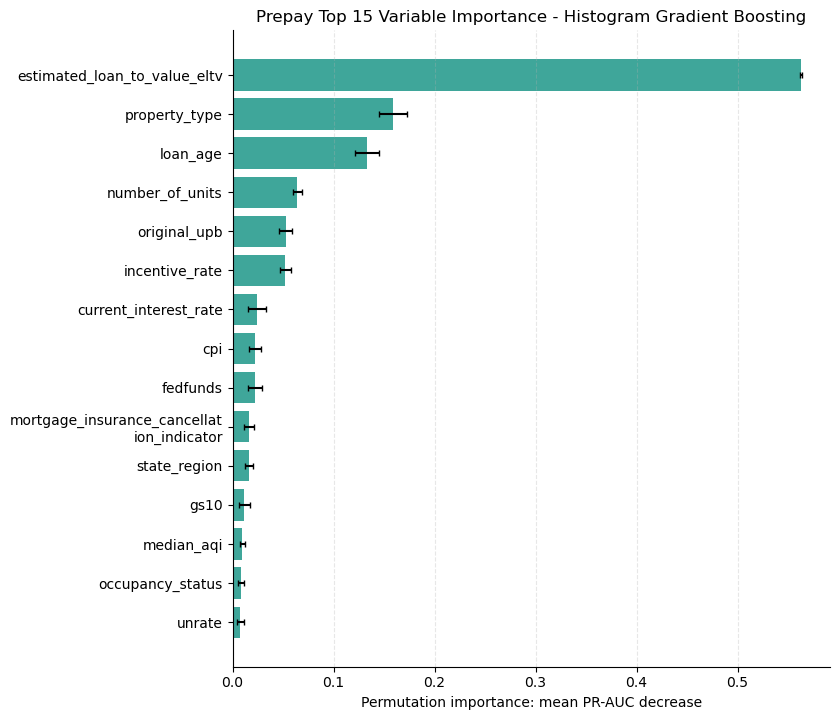

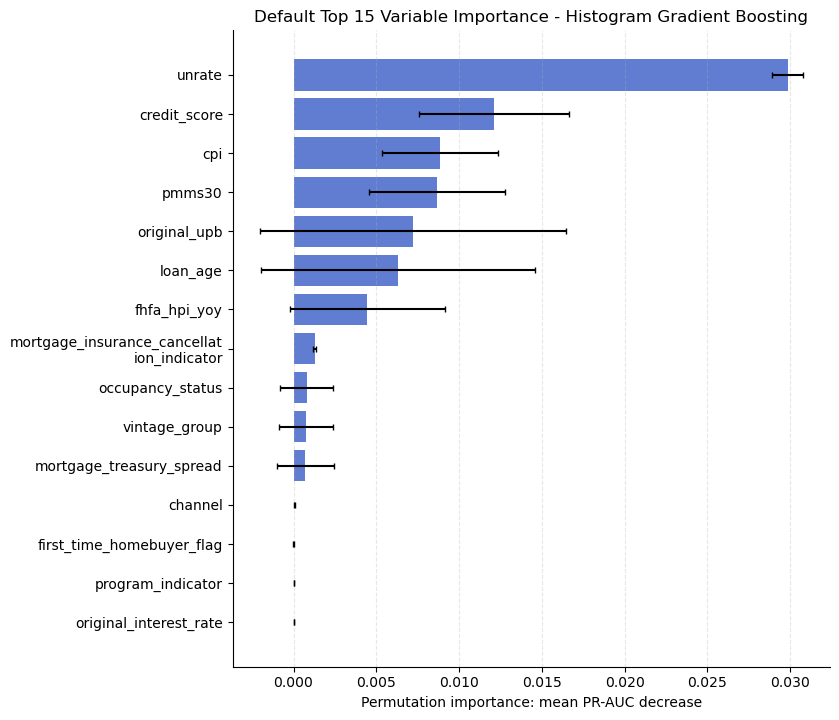

Saved prepay variable importance chart to /Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts/prepay_top15_variable_importance.png
Saved default variable importance chart to /Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts/default_top15_variable_importance.png


In [11]:
import os
from pathlib import Path

MPLCONFIGDIR = Path('/tmp/freddie_mortgage_matplotlib_cache')
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
from textwrap import fill

TOP_N_IMPORTANCE = 15
TREE_IMPORTANCE_PATH = ARTIFACT_DIR / 'tree_permutation_source_feature_importance.csv'
TREE_METRICS_PATH = ARTIFACT_DIR / 'tree_model_metrics_compare.csv'

if not TREE_IMPORTANCE_PATH.exists() or not TREE_METRICS_PATH.exists():
    raise FileNotFoundError(
        'Missing already-run tree artifacts. Rerun the tree experiment cells first.'
    )

tree_importance = pd.read_csv(TREE_IMPORTANCE_PATH)
tree_metrics_from_file = pd.read_csv(TREE_METRICS_PATH)

best_tree_model_by_outcome = (
    tree_metrics_from_file
    .sort_values(['outcome', 'roc_auc'], ascending=[True, False])
    .groupby('outcome', as_index=True)
    .head(1)
    .set_index('outcome')
    ['model']
    .to_dict()
)

model_display = {
    'random_forest': 'Random Forest',
    'hist_gradient_boosting': 'Histogram Gradient Boosting',
}
outcome_colors = {
    'prepay': '#2a9d8f',
    'default': '#4f6fce',
}


def plot_top_variable_importance(outcome: str, top_n: int = TOP_N_IMPORTANCE):
    model_name = best_tree_model_by_outcome[outcome]
    plot_df = (
        tree_importance
        .loc[
            tree_importance['outcome'].eq(outcome)
            & tree_importance['model'].eq(model_name)
        ]
        .sort_values('permutation_importance_mean', ascending=False)
        .head(top_n)
        .sort_values('permutation_importance_mean', ascending=True)
        .copy()
    )

    if plot_df.empty:
        raise ValueError(f'No tree permutation importance rows found for {outcome}/{model_name}')

    labels = [fill(feature, width=28) for feature in plot_df['source_feature']]
    fig_height = max(4.5, 0.38 * len(plot_df) + 1.6)
    fig, ax = plt.subplots(figsize=(8.5, fig_height))

    ax.barh(
        labels,
        plot_df['permutation_importance_mean'],
        xerr=plot_df['permutation_importance_std'],
        color=outcome_colors.get(outcome, '#5a7d9a'),
        alpha=0.9,
        capsize=2,
    )
    ax.set_title(
        f'{outcome.title()} Top {top_n} Variable Importance - {model_display.get(model_name, model_name)}'
    )
    ax.set_xlabel('Permutation importance: mean PR-AUC decrease')
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    output_path = ARTIFACT_DIR / f'{outcome}_top{top_n}_variable_importance.png'
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()

    return plot_df.sort_values('permutation_importance_mean', ascending=False), output_path


prepay_top_variable_importance, prepay_importance_plot_path = plot_top_variable_importance('prepay')
default_top_variable_importance, default_importance_plot_path = plot_top_variable_importance('default')

print(f'Saved prepay variable importance chart to {prepay_importance_plot_path}')
print(f'Saved default variable importance chart to {default_importance_plot_path}')


## Comparing Tree Importance With L1 Feature Screening

Compare L1 top 15 selected variables with Histogram Gradient Boosting top 15 tree-importance variables. Prepay and default are shown as separate vertical tables, with one variable per cell.


In [17]:
TOP_N_TREE_L1_COMPARISON = 15
TREE_MODEL_FOR_COMPARISON = 'hist_gradient_boosting'
L1_SELECTED_FEATURES_PATH = ARTIFACT_DIR / 'l1_selected_source_features.csv'
TREE_IMPORTANCE_PATH = ARTIFACT_DIR / 'tree_permutation_source_feature_importance.csv'

required_comparison_paths = {
    'L1 selected source features': L1_SELECTED_FEATURES_PATH,
    'tree permutation importance': TREE_IMPORTANCE_PATH,
}
missing_comparison_paths = {
    name: path for name, path in required_comparison_paths.items()
    if not path.exists()
}
if missing_comparison_paths:
    raise FileNotFoundError(
        'Missing already-run comparison artifacts: '
        f'{missing_comparison_paths}'
    )

l1_selected_features = pd.read_csv(L1_SELECTED_FEATURES_PATH)
tree_importance = pd.read_csv(TREE_IMPORTANCE_PATH)


def build_tree_l1_vertical_table(outcome: str, top_n: int = TOP_N_TREE_L1_COMPARISON) -> pd.DataFrame:
    l1_list = (
        l1_selected_features
        .loc[l1_selected_features['outcome'].eq(outcome)]
        .sort_values('feature_order')
        .head(top_n)
        ['source_feature']
        .tolist()
    )
    tree_list = (
        tree_importance
        .loc[
            tree_importance['outcome'].eq(outcome)
            & tree_importance['model'].eq(TREE_MODEL_FOR_COMPARISON)
        ]
        .sort_values('permutation_importance_mean', ascending=False)
        .head(top_n)
        ['source_feature']
        .tolist()
    )

    l1_set = set(l1_list)
    tree_set = set(tree_list)

    both_selected = [feature for feature in tree_list if feature in l1_set]
    l1_only = [feature for feature in l1_list if feature not in tree_set]
    tree_only = [feature for feature in tree_list if feature not in l1_set]

    max_rows = max(len(both_selected), len(l1_only), len(tree_only))

    def pad(values: list[str]) -> list[str]:
        return values + [''] * (max_rows - len(values))

    return pd.DataFrame({
        'both_selected': pad(both_selected),
        'L1_only': pad(l1_only),
        'tree_only': pad(tree_only),
    })


prepay_tree_l1_comparison = build_tree_l1_vertical_table('prepay')
default_tree_l1_comparison = build_tree_l1_vertical_table('default')

prepay_tree_l1_comparison_path = ARTIFACT_DIR / 'prepay_tree_l1_feature_screening_comparison.csv'
default_tree_l1_comparison_path = ARTIFACT_DIR / 'default_tree_l1_feature_screening_comparison.csv'
prepay_tree_l1_comparison.to_csv(prepay_tree_l1_comparison_path, index=False)
default_tree_l1_comparison.to_csv(default_tree_l1_comparison_path, index=False)

print('Prepay: Histogram Gradient Boosting vs L1')
display(prepay_tree_l1_comparison)

print('Default: Histogram Gradient Boosting vs L1')
display(default_tree_l1_comparison)

print(f'Saved prepay comparison table to {prepay_tree_l1_comparison_path}')
print(f'Saved default comparison table to {default_tree_l1_comparison_path}')


Prepay: Histogram Gradient Boosting vs L1


,both_selected,L1_only,tree_only
0,estimated_loan_to_value_eltv,mortgage_treasury_spread,current_interest_rate
1,property_type,fhfa_hpi_yoy,state_region
2,loan_age,dti,unrate
3,number_of_units,,
4,original_upb,,
5,incentive_rate,,
6,cpi,,
7,fedfunds,,
8,mortgage_insurance_cancellation_indicator,,
9,gs10,,


Default: Histogram Gradient Boosting vs L1


,both_selected,L1_only,tree_only
0,unrate,gs10,credit_score
1,loan_age,cpi_yoy,cpi
2,mortgage_insurance_cancellation_indicator,spread_at_origination,pmms30
3,occupancy_status,mortgage_insurance_percentage_mi_pct,original_upb
4,mortgage_treasury_spread,number_of_borrowers,fhfa_hpi_yoy
5,channel,current_interest_rate,vintage_group
6,original_interest_rate,loan_purpose,first_time_homebuyer_flag
7,,state_region,program_indicator


Saved prepay comparison table to /Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts/prepay_tree_l1_feature_screening_comparison.csv
Saved default comparison table to /Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts/default_tree_l1_feature_screening_comparison.csv
